<a href="https://colab.research.google.com/github/suhani-00123/Telco_Customer_Churn_Segmentation/blob/main/Telco_customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CUSTOMER CHURN SEGMENTATION PROJECT**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_excel("Telco_customer_churn.xlsx")

In [ ]:
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [ ]:
df.shape

(7043, 33)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


In [ ]:
churn_rate = df["Churn Label"].value_counts(normalize=True) * 100
print(churn_rate)

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


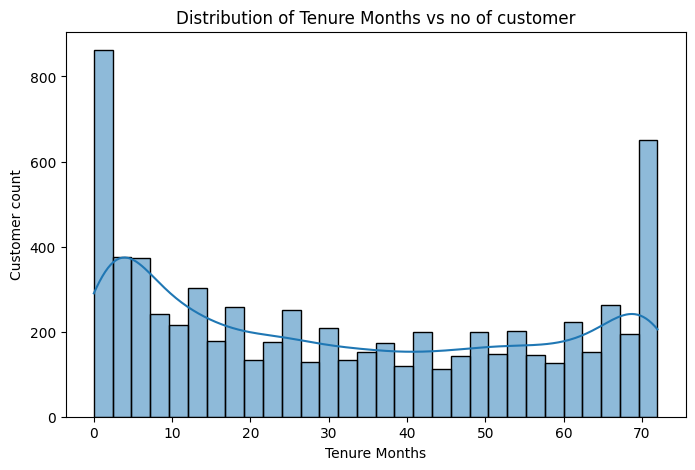

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure Months'], bins=30, kde=True)
plt.xlabel('Tenure Months')
plt.ylabel('Customer count')
plt.title('Distribution of Tenure Months vs no of customer')
plt.show()



In [ ]:
df['Tenure Months'].max()

72

In [ ]:
df['Tenure Months'].min()

0

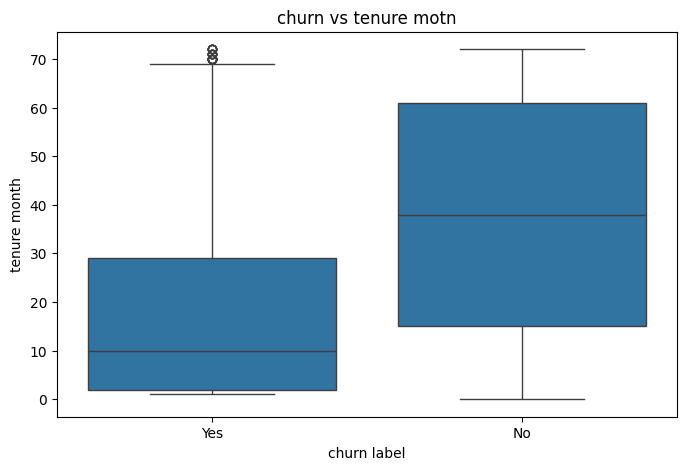

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label', y='Tenure Months' , data=df)
plt.xlabel('churn label')
plt.ylabel('tenure month')
plt.title('churn vs tenure motn')
plt.show()

In [ ]:
df['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
df[df['Churn Label']=='yes']

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason


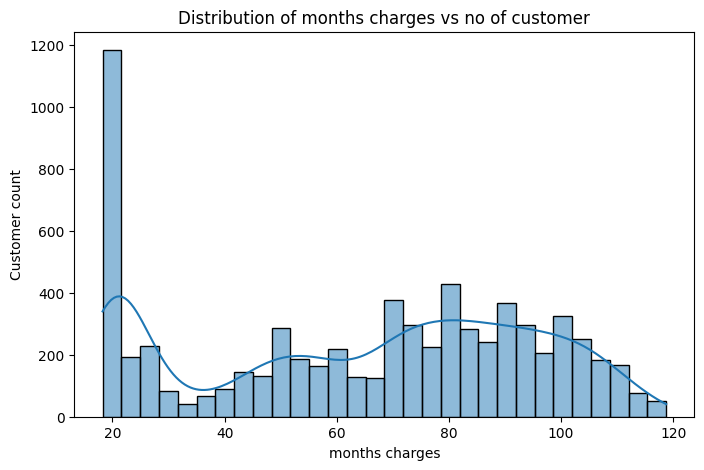

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Monthly Charges'], bins=30, kde=True)
plt.xlabel('months charges')
plt.ylabel('Customer count')
plt.title('Distribution of months charges vs no of customer')
plt.show()

In [ ]:
df['Monthly Charges'].max()

118.75

In [ ]:
df['Monthly Charges'].min()

18.25

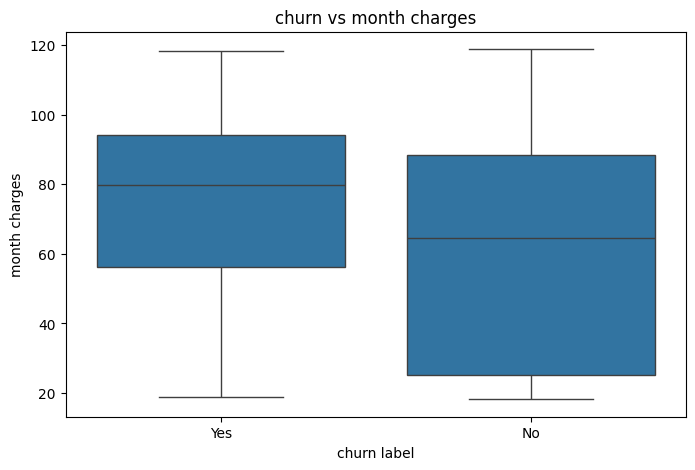

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label', y='Monthly Charges' , data=df)
plt.xlabel('churn label')
plt.ylabel('month charges')
plt.title('churn vs month charges')
plt.show()



In [ ]:
df[df['Churn Label']=='Yes']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [ ]:
df[df['Churn Label']=='No']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,25.100
0.50,64.425
0.75,88.400


In [ ]:
df['Monthly Charges'].describe()

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [ ]:

df['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,35.50
0.50,70.35
0.75,89.85


In [ ]:
df['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

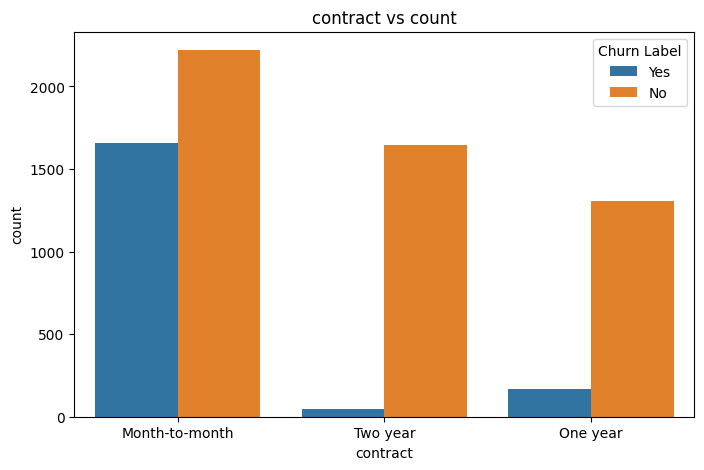

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn Label', data=df)
plt.xlabel('contract')
plt.ylabel('count')
plt.title('contract vs count')
plt.show()

In [ ]:
df['Internet Service'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

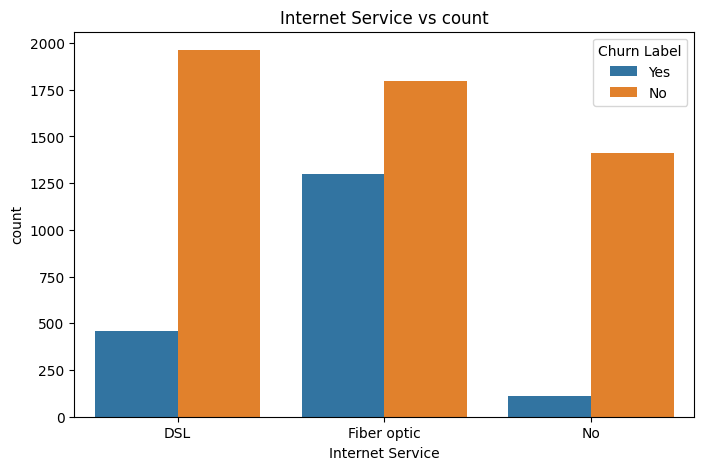

In [ ]:

plt.figure(figsize=(8,5))
sns.countplot(x='Internet Service', hue='Churn Label', data=df)
plt.xlabel('Internet Service')
plt.ylabel('count')
plt.title('Internet Service vs count')
plt.show()

In [ ]:
df['Payment Method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

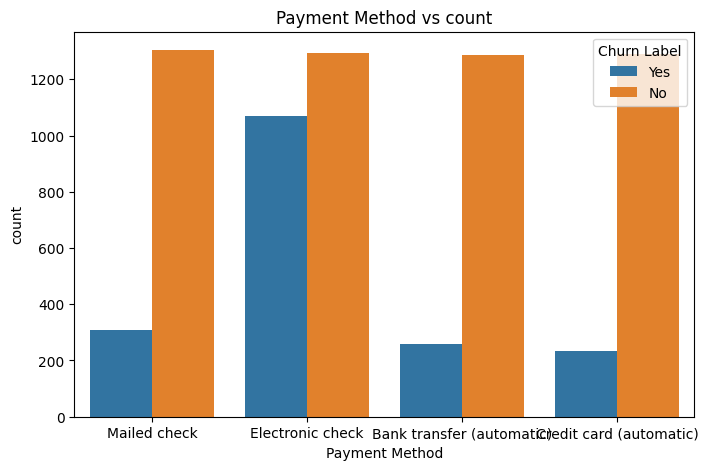

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Payment Method', hue='Churn Label', data=df)
plt.xlabel('Payment Method')
plt.ylabel('count')
plt.title('Payment Method vs count')
plt.show()

In [ ]:
df['Tech Support'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

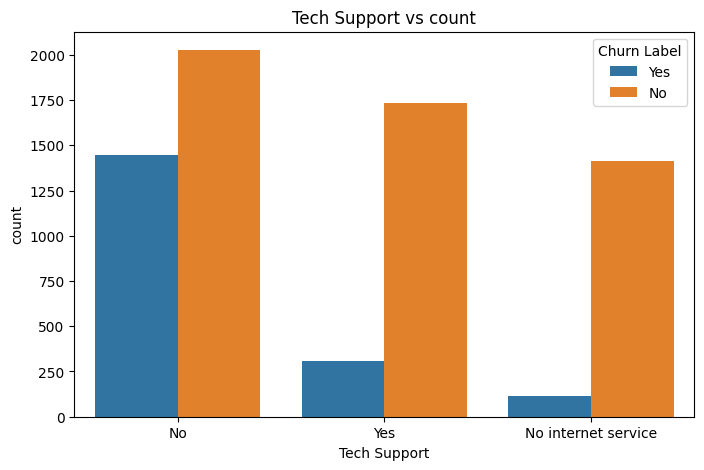

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Tech Support', hue='Churn Label', data=df)
plt.xlabel('Tech Support')
plt.ylabel('count')
plt.title('Tech Support vs count')
plt.show()

In [ ]:
avg_tenure=df.groupby("Churn Label")['Tenure Months'].mean()

In [ ]:
avg_tenure

,Tenure Months
Churn Label,
No,37.569965
Yes,17.979133


In [ ]:
numerical_cols=['Tenure Months','Monthly Charges','Churn Value', 'Churn Score', 'CLTV']
correlation_matrix=df[numerical_cols].corr()

In [ ]:
correlation_matrix

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


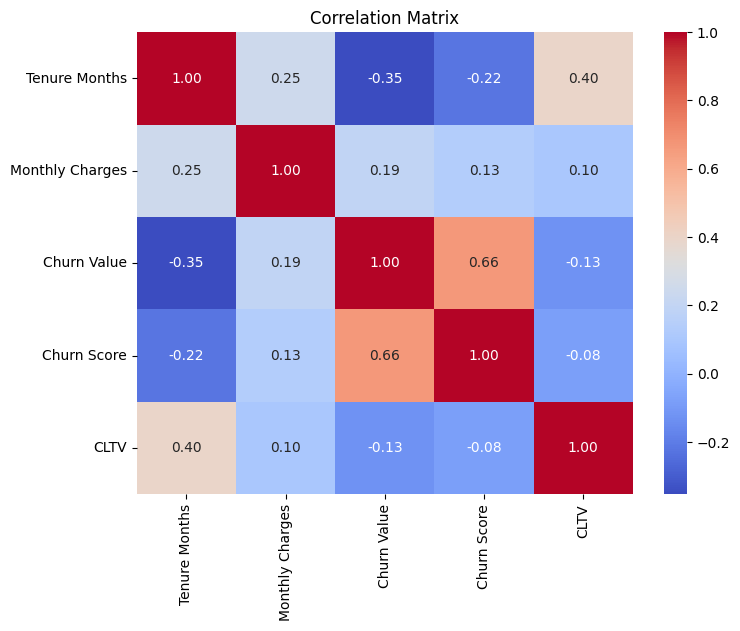

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Matrix")
plt.show()

In [ ]:

contract_churn=pd.crosstab(df['Contract'], df['Churn Label'],normalize='index')
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


Data Cleaning


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.5
3,3046.05
4,5036.3
...,...
7038,1419.4
7039,1990.5
7040,7362.9
7041,346.45


In [ ]:
df['Total Charges']=pd.to_numeric(df['Total Charges'],errors='coerce')
df['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.50
3,3046.05
4,5036.30
...,...
7038,1419.40
7039,1990.50
7040,7362.90
7041,346.45


In [ ]:
df['Total Charges'].dtype

dtype('float64')

In [ ]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [ ]:
df[df['Total Charges'].isnull()]['Tenure Months'].shape

(11,)

In [ ]:
df[df['Total Charges'].isnull()]['Total Charges'].fillna(0)

,Total Charges
2234,0.0
2438,0.0
2568,0.0
2667,0.0
2856,0.0
4331,0.0
4687,0.0
5104,0.0
5719,0.0
6772,0.0


In [ ]:
for col in df.columns:
    print(col)
    print(df[col].unique())

CustomerID
['3668-QPYBK' '9237-HQITU' '9305-CDSKC' ... '2234-XADUH' '4801-JZAZL'
 '3186-AJIEK']
Count
[1]
Country
['United States']
State
['California']
City
['Los Angeles' 'Beverly Hills' 'Huntington Park' ... 'Standish' 'Tulelake'
 'Olympic Valley']
Zip Code
[90003 90005 90006 ... 96128 96134 96146]
Lat Long
['33.964131, -118.272783' '34.059281, -118.30742' '34.048013, -118.293953'
 ... '40.346634, -120.386422' '41.813521, -121.492666'
 '39.191797, -120.212401']
Latitude
[33.964131 34.059281 34.048013 ... 40.346634 41.813521 39.191797]
Longitude
[-118.272783 -118.30742  -118.293953 ... -120.386422 -121.492666
 -120.212401]
Gender
['Male' 'Female']
Senior Citizen
['No' 'Yes']
Partner
['No' 'Yes']
Dependents
['No' 'Yes']
Tenure Months
[ 2  8 28 49 10  1 47 17  5 34 11 15 18  9  7 12 25 68 55 37  3 27 20  4
 58 53 13  6 19 59 16 52 24 32 38 54 43 63 21 69 22 61 60 48 40 23 39 35
 56 65 33 30 45 46 62 70 50 44 71 26 14 41 66 64 29 42 67 51 31 57 36 72
  0]
Phone Service
['Yes' 'No']
Mult

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
drop_columns=['CustomerID','Count','Country','State','Zip Code','Lat Long','Latitude','Longitude','Churn Label','Churn Score','CLTV','Churn Reason']

In [ ]:
df=df.drop(columns=drop_columns)

In [ ]:
df.shape

(7043, 21)

In [ ]:
df_encoded=pd.get_dummies(df,drop_first=True)

In [ ]:
df_encoded.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,City_Acton,City_Adelanto,City_Adin,City_Agoura Hills,City_Aguanga,City_Ahwahnee,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,False,False


In [ ]:
df_encoded.shape

(7043, 1159)

In [ ]:
df_encoded

,Tenure Months,Monthly Charges,Total Charges,Churn Value,City_Acton,City_Adelanto,City_Adin,City_Agoura Hills,City_Aguanga,City_Ahwahnee,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,72,21.15,1419.40,0,False,False,False,False,False,False,...,True,False,True,False,False,True,True,False,False,False
7039,24,84.80,1990.50,0,False,True,False,False,False,False,...,False,True,False,True,True,False,True,False,False,True
7040,72,103.20,7362.90,0,False,False,False,False,False,False,...,False,True,False,True,True,False,True,True,False,False
7041,11,29.60,346.45,0,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False


In [ ]:
X=df_encoded.drop('Churn Value',axis=1)
Y=df_encoded['Churn Value']

In [ ]:
X.shape

(7043, 1158)

In [ ]:
Y.shape

(7043,)

In [ ]:
print(X)

      Tenure Months  Monthly Charges  Total Charges  City_Acton  \
0                 2            53.85         108.15       False   
1                 2            70.70         151.65       False   
2                 8            99.65         820.50       False   
3                28           104.80        3046.05       False   
4                49           103.70        5036.30       False   
...             ...              ...            ...         ...   
7038             72            21.15        1419.40       False   
7039             24            84.80        1990.50       False   
7040             72           103.20        7362.90       False   
7041             11            29.60         346.45       False   
7042             66           105.65        6844.50       False   

      City_Adelanto  City_Adin  City_Agoura Hills  City_Aguanga  \
0             False      False              False         False   
1             False      False              False         Fal

In [ ]:
print(Y)

0       1
1       1
2       1
3       1
4       1
       ..
7038    0
7039    0
7040    0
7041    0
7042    0
Name: Churn Value, Length: 7043, dtype: int64


MACHINE LEARNING IMPLEMENTATION

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,Y_train,Y_test = train_test_split(
    X,Y,test_size=0.2,random_state=2
)

In [ ]:
X_train.shape

(5634, 1158)

In [ ]:
X_test.shape

(1409, 1158)

In [ ]:
Y_train.shape

(5634,)

In [ ]:
Y_test.shape

(1409,)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)

In [ ]:
rf_model.fit(X_train,Y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred=rf_model.predict(X_test)

In [ ]:
y_pred

array([1, 0, 1, ..., 0, 0, 1])

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy=accuracy_score(Y_test,y_pred)

In [ ]:
accuracy=accuracy_score(Y_test,y_pred)
print(accuracy)

0.8041163946061036


In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
cm=confusion_matrix(Y_test,y_pred)

In [ ]:
print(cm)

[[958  70]
 [206 175]]


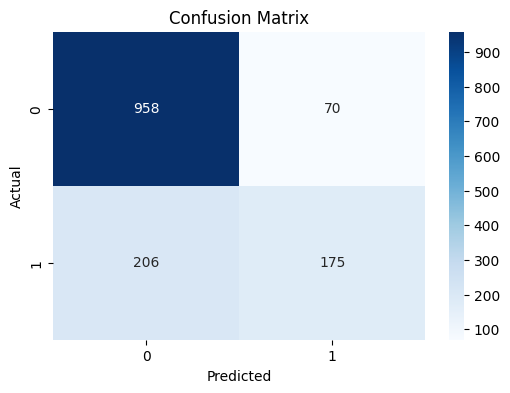

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(Y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.93      0.87      1028
           1       0.71      0.46      0.56       381

    accuracy                           0.80      1409
   macro avg       0.77      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



Approach 1 - Handle class **imbalance**

In [ ]:
rf_balanced=RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')
rf_balanced.fit(X_train,Y_train)
y_pred_balanced=rf_balanced.predict(X_test)
accuracy_balanced=accuracy_score(Y_test, y_pred_balanced)
cm_balanced=confusion_matrix(Y_test, y_pred_balanced)
print (accuracy_balanced,cm_balanced)
print (classification_report(Y_test, y_pred_balanced))

0.8055358410220014 [[944  84]
 [190 191]]
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1028
           1       0.69      0.50      0.58       381

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.79      1409



Approach 2 - Hyperparameter **Tuning**

In [ ]:
rf_tuned=RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42,class_weight='balanced')
rf_tuned.fit(X_train,Y_train)
y_pred_tuned=rf_tuned.predict(X_test)
print (classification_report(Y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1028
           1       0.54      0.83      0.66       381

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.77      0.78      1409



Approach 3 - Feature Importance Analysis


In [ ]:
import pandas as pd
feature_importance =pd.DataFrame({
    'Features':X.columns,
    'Importance':rf_tuned.feature_importances_
})
feature_importance =feature_importance.sort_values(by='Importance',ascending=False)
print(feature_importance )

                          Features  Importance
1153             Contract_Two year    0.102205
0                    Tenure Months    0.099213
2                    Total Charges    0.072229
1138  Internet Service_Fiber optic    0.067885
1134                Dependents_Yes    0.066931
...                            ...         ...
468              City_Johannesburg    0.000000
705                    City_Oakley    0.000000
89                      City_Biggs    0.000000
780                 City_Pittsburg    0.000000
32                    City_Antioch    0.000000

[1158 rows x 2 columns]


In [ ]:
print(feature_importance.tail(15))

               Features    Importance
785        City_Platina  3.114101e-08
235      City_Crestline  2.613044e-08
965    City_Springville  2.017116e-08
210         City_Colfax  4.604461e-09
685         City_Nipton  3.894937e-09
612        City_Mendota  1.592715e-09
1069  City_Walnut Grove  3.250545e-18
494      City_La Grange  0.000000e+00
15     City_Aliso Viejo  0.000000e+00
464      City_Jamestown  0.000000e+00
468   City_Johannesburg  0.000000e+00
705         City_Oakley  0.000000e+00
89           City_Biggs  0.000000e+00
780      City_Pittsburg  0.000000e+00
32         City_Antioch  0.000000e+00


In [ ]:
X_selected=X.drop(['Phone Service_Yes','Multiple Lines_No phone service'],axis=1)

In [ ]:
X_train_sel, X_test_sel, Y_train_sel, Y_test_sel = train_test_split(
    X_selected, Y, test_size=0.2, random_state=42)

In [ ]:
rf_selected=RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42,class_weight='balanced')
rf_selected.fit(X_train_sel,Y_train_sel)
y_pred_selected=rf_selected.predict(X_test_sel)
print("Accuracy:", accuracy_score(Y_test, y_pred))
print (classification_report(Y_test_sel, y_pred_selected))



Accuracy: 0.8041163946061036
              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1009
           1       0.53      0.81      0.64       400

    accuracy                           0.74      1409
   macro avg       0.72      0.76      0.72      1409
weighted avg       0.80      0.74      0.75      1409



In [ ]:
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score

In [ ]:
n_estimators_list=[100,200,300,400,500]
max_depth_list=[5,10,15,20]
results=[]
for n_trees in n_estimators_list:
  for depth in max_depth_list:
    rf=RandomForestClassifier(n_estimators=n_trees,max_depth=depth,random_state=42,class_weight='balanced')
    rf.fit(X_train,Y_train)
    y_pred=rf.predict(X_test)
    accuracy=accuracy_score(Y_test,y_pred)
    recall=recall_score(Y_test,y_pred)
    precision=precision_score(Y_test,y_pred)
    f1=f1_score(Y_test,y_pred)
    results.append ({'Trees': n_trees, 'Depth':depth, 'Accuracy':accuracy,'Recall':recall,'precision': precision,'F1 Score':f1})
result_df=pd.DataFrame(results)
result_df=result_df.sort_values(by=['Recall','Accuracy'],ascending=False)
print(result_df.head(20))

    Trees  Depth  Accuracy    Recall  precision  F1 Score
0     100      5  0.734564  0.858268   0.505410  0.636187
8     300      5  0.744500  0.845144   0.516854  0.641434
12    400      5  0.745209  0.842520   0.517742  0.641359
16    500      5  0.744500  0.842520   0.516908  0.640719
9     300     10  0.765791  0.826772   0.544041  0.656250
4     200      5  0.744500  0.826772   0.517241  0.636364
5     200     10  0.767211  0.824147   0.546087  0.656904
13    400     10  0.766501  0.821522   0.545296  0.655497
17    500     10  0.766501  0.821522   0.545296  0.655497
1     100     10  0.766501  0.818898   0.545455  0.654774
10    300     15  0.782115  0.797900   0.569288  0.664481
18    500     15  0.781405  0.795276   0.568480  0.663020
2     100     15  0.782115  0.790026   0.570076  0.662266
14    400     15  0.779986  0.790026   0.566855  0.660088
6     200     15  0.782115  0.787402   0.570342  0.661521
19    500     20  0.798439  0.769029   0.599182  0.673563
15    400     

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(random_state=42)
model.fit(X_train, Y_train)

y_pred = model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(Y_test, y_pred))

print(classification_report(Y_test, y_pred))

Accuracy: 0.8019872249822569
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1028
           1       0.68      0.51      0.58       381

    accuracy                           0.80      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [ ]:
from sklearn.model_selection import cross_val_score
final_rf=RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42,class_weight='balanced')

In [ ]:
cv_accuracy=cross_val_score(final_rf,X,Y,cv=5,scoring='accuracy')

In [ ]:
cv_accuracy

array([0.76437189, 0.7523066 , 0.72888573, 0.73934659, 0.74076705])

In [ ]:
cv_accuracy.mean()

np.float64(0.7451355732627911)

In [ ]:
cv_recall=cross_val_score(final_rf,X,Y,cv=5,scoring='recall')

In [ ]:
cv_recall

array([0.83957219, 0.82085561, 0.81818182, 0.79946524, 0.78016086])

In [ ]:
cv_recall.mean()

np.float64(0.8116471448438014)

In [ ]:
from sklearn.metrics import roc_auc_score,roc_curve

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
y_prob=rf_tuned.predict_proba(X)

In [ ]:
y_prob1=rf_tuned.predict_proba(X_test)

In [ ]:
churn_probability= y_prob[:,1]

In [ ]:
churn_prob=y_prob1[:,1]

In [ ]:
fpr,tpr,threshold = roc_curve(Y_test,churn_prob)
auc_score= roc_auc_score(Y_test,churn_prob)
print(auc_score)

0.8582115465138841


**Customer Segmentation**

In [ ]:
segmentation_data=pd.DataFrame({
  'Tenure Months':X['Tenure Months'],
  'Monthly Charges':X['Monthly Charges'],
  'Total Charges':X['Total Charges'],
  'Churn Probability':churn_probability})

In [ ]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
0,2,53.85,108.15,0.604742
1,2,70.70,151.65,0.706508
2,8,99.65,820.50,0.655629
3,28,104.80,3046.05,0.468906
4,49,103.70,5036.30,0.454038
...,...,...,...,...
7038,72,21.15,1419.40,0.130353
7039,24,84.80,1990.50,0.272381
7040,72,103.20,7362.90,0.346171
7041,11,29.60,346.45,0.498693


Implementation of **kmeans**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
segmentation_data=segmentation_data.fillna(segmentation_data.mean())

In [ ]:
scaled_data=scaler.fit_transform(segmentation_data)
print(scaled_data[:5])

[[-1.23672422 -0.36266036 -0.96039939  0.84346433]
 [-1.23672422  0.19736523 -0.94119274  1.34944499]
 [-0.99240204  1.1595457  -0.64587379  1.09647394]
 [-0.17799476  1.33071079  0.33677864  0.16808754]
 [ 0.67713287  1.29415125  1.2155385   0.09416628]]


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

...

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

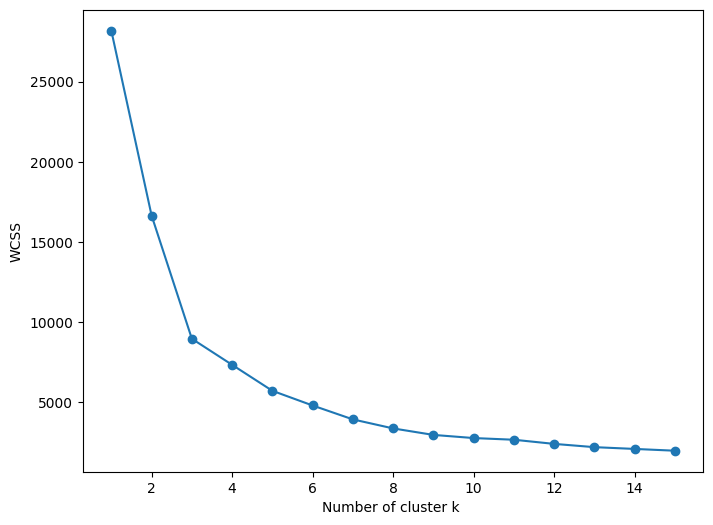

In [ ]:
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,16):
  kmeans=KMeans(n_clusters=k, random_state=42)
  kmeans.fit(scaled_data)
  wcss.append(kmeans.inertia_)
  plt.figure(figsize=(8,6))
plt.plot(range(1,16),wcss,marker='o')
plt.xlabel("Number of cluster k ")
plt.ylabel("WCSS")
plt.show()

In [ ]:
kmeans=KMeans(n_clusters=3,random_state=42)

In [ ]:
clusters=kmeans.fit_predict(scaled_data)

In [ ]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
0,2,53.85,108.15,0.604742
1,2,70.70,151.65,0.706508
2,8,99.65,820.50,0.655629
3,28,104.80,3046.05,0.468906
4,49,103.70,5036.30,0.454038
...,...,...,...,...
7038,72,21.15,1419.40,0.130353
7039,24,84.80,1990.50,0.272381
7040,72,103.20,7362.90,0.346171
7041,11,29.60,346.45,0.498693


In [ ]:
segmentation_data['Cluster']=clusters

In [ ]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster
0,2,53.85,108.15,0.604742,2
1,2,70.70,151.65,0.706508,2
2,8,99.65,820.50,0.655629,2
3,28,104.80,3046.05,0.468906,1
4,49,103.70,5036.30,0.454038,1
...,...,...,...,...,...
7038,72,21.15,1419.40,0.130353,0
7039,24,84.80,1990.50,0.272381,2
7040,72,103.20,7362.90,0.346171,1
7041,11,29.60,346.45,0.498693,2


In [ ]:
cluster_summary=segmentation_data.groupby('Cluster').mean()

In [ ]:
cluster_summary

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
Cluster,,,,
0,31.821890,26.403924,885.253151,0.220620
1,58.147570,89.167878,5188.377441,0.387437
2,12.548376,71.592263,953.202603,0.617548


In [ ]:
cluster_names={
    0:'Budget Loyal Customers',
    1:'High Risk New Customers',
    2:'Loyal Premium Customers'
}

In [ ]:
segmentation_data['Cluster Segment']=segmentation_data['Cluster'].map(cluster_names)

In [ ]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster,Cluster Segment
0,2,53.85,108.15,0.604742,2,Loyal Premium Customers
1,2,70.70,151.65,0.706508,2,Loyal Premium Customers
2,8,99.65,820.50,0.655629,2,Loyal Premium Customers
3,28,104.80,3046.05,0.468906,1,High Risk New Customers
4,49,103.70,5036.30,0.454038,1,High Risk New Customers
...,...,...,...,...,...,...
7038,72,21.15,1419.40,0.130353,0,Budget Loyal Customers
7039,24,84.80,1990.50,0.272381,2,Loyal Premium Customers
7040,72,103.20,7362.90,0.346171,1,High Risk New Customers
7041,11,29.60,346.45,0.498693,2,Loyal Premium Customers


In [ ]:
plt.figure(figsize=(10,8))

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Axes: xlabel='Tenure Months', ylabel='Churn Probability'>

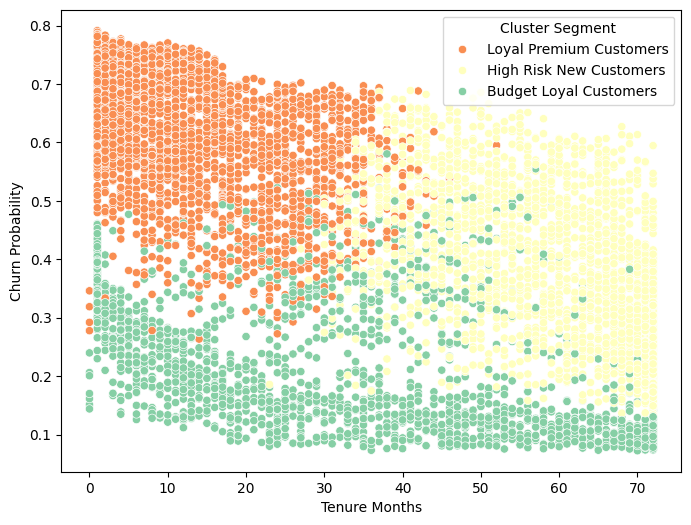

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Tenure Months',y='Churn Probability',hue='Cluster Segment',data=segmentation_data,palette='Spectral')

<Axes: xlabel='Monthly Charges', ylabel='Churn Probability'>

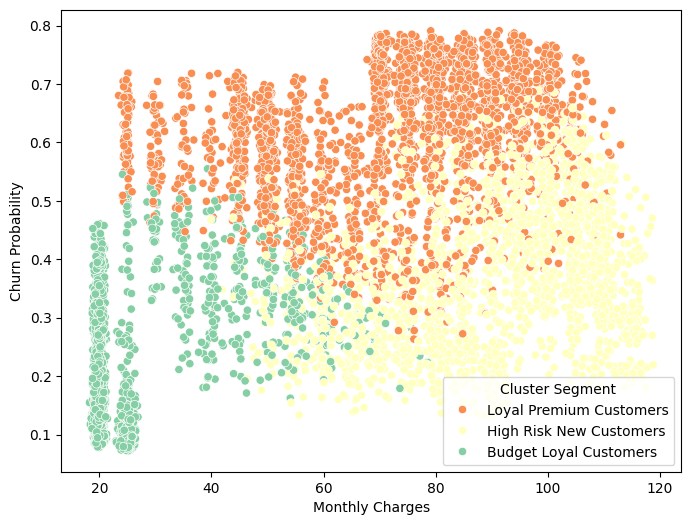

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Monthly Charges',y='Churn Probability',hue='Cluster Segment',data=segmentation_data,palette='Spectral')

<Axes: xlabel='Total Charges', ylabel='Churn Probability'>

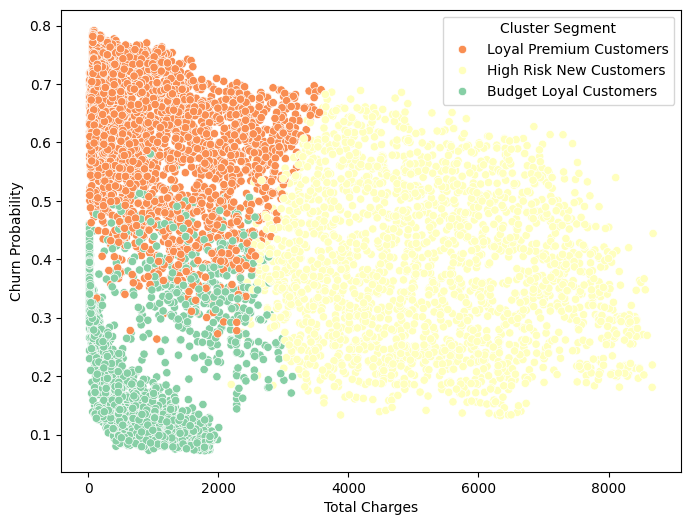

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Total Charges',y='Churn Probability',hue='Cluster Segment',data=segmentation_data,palette='Spectral')

In [ ]:
segmentation_data.groupby('Cluster Segment').mean()

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster
Cluster Segment,,,,,
Budget Loyal Customers,31.821890,26.403924,885.253151,0.220620,0.0
High Risk New Customers,58.147570,89.167878,5188.377441,0.387437,1.0
Loyal Premium Customers,12.548376,71.592263,953.202603,0.617548,2.0
